In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated, Literal

In [4]:
class state(TypedDict):
    post_content:str
    user_reputation:str
    formatted_post:str
    content_flag:str
    result:str

In [7]:
def format_post(state:state):
    formatted=f"User ({state['user_reputation']}) posted: {state['post_content']}"
    return {"formatted_post": formatted}

def analyze_content(state: state):
    content = state['post_content'].lower()
    
    if 'spam' in content or 'buy now' in content:
        flag = 'rejected'
    elif state['user_reputation'] == 'new_user':
        flag = 'review'
    else:
        flag = 'approved'
        
    return {'content_flag': flag}

def approve_post(state: state):
    result = 'Post published successfully to the timeline.'
    return {'result': result}

def flag_for_review(state: state):
    result = 'Post sent to the human moderation queue.'
    return {'result': result}

def reject_post(state: state):
    result = 'Post automatically deleted due to policy violation.'
    return {'result': result}

def check_condition(state: state) -> Literal["approve_post", "flag_for_review", "reject_post"]:
    if state['content_flag'] == 'approved':
        return "approve_post"
    elif state['content_flag'] == 'review':
        return "flag_for_review"
    else:
        return "reject_post"

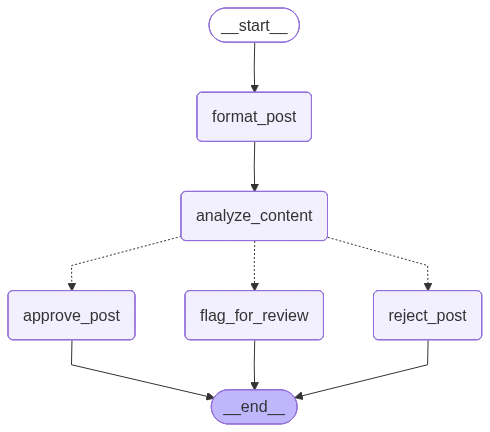

In [9]:
graph = StateGraph(state)

# add the nodes
graph.add_node('format_post', format_post)
graph.add_node('analyze_content', analyze_content)
graph.add_node('approve_post', approve_post)
graph.add_node('flag_for_review', flag_for_review)
graph.add_node('reject_post', reject_post)


# add the edges
graph.add_edge(START, 'format_post')
graph.add_edge('format_post', 'analyze_content')

# Add conditional edges
graph.add_conditional_edges('analyze_content', check_condition)

# Connect all branches to END
graph.add_edge('approve_post', END)
graph.add_edge('flag_for_review', END)
graph.add_edge('reject_post', END)

workflow = graph.compile()
workflow

In [10]:
initial_state = {
    'post_content': "Check out this amazing new product!", 
    'user_reputation': "new_user"
}

result = workflow.invoke(initial_state)
result

{'post_content': 'Check out this amazing new product!',
 'user_reputation': 'new_user',
 'formatted_post': 'User (new_user) posted: Check out this amazing new product!',
 'content_flag': 'review',
 'result': 'Post sent to the human moderation queue.'}

In [13]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
load_dotenv()
import os

In [14]:
model=ChatOpenAI(model=os.getenv("MODEL_NAME"))

In [15]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')



class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [16]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)
prompt = 'What is the sentiment of the following review - The software too bad'
structured_model2.invoke(prompt)

DiagnosisSchema(issue_type='Other', tone='angry', urgency='high')

In [17]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [18]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [19]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

In [20]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [21]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

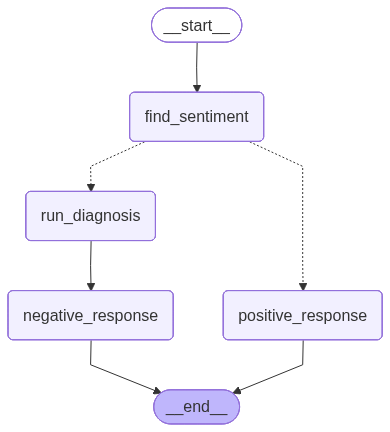

In [22]:
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges with conditions
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
workflow

In [23]:
intial_state={
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!"
}
result = workflow.invoke(intial_state)
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!',
 'sentiment': 'positive',
 'response': "Thank you so much for your wonderful review! We're thrilled to hear that our software has made a positive impact on your workflow and helped save valuable time. Your recommendation means a lot to us and motivates our team to keep delivering the best possible experience.\n\nIf you have a moment, we would greatly appreciate it if you could share your feedback on our website as well. Your insights help us grow and assist others in making informed decisions. Thank you again for your support!"}